# Stage 1 — Data Exploration
**Project:** Gendered Citation Networks in French Electoral Manifestos

**Goal:** Load the Archelec manifesto texts, understand their structure, and produce descriptive statistics for the paper.

By the end of this notebook you will know:
- How many manifestos exist per election year
- What a manifesto looks like (text quality, length, OCR noise)
- The filename naming convention (we'll use it to link texts to metadata)

## 0. Setup

In [49]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from collections import Counter

# Root of your project
PROJECT_ROOT = Path("..")
TEXT_ROOT    = PROJECT_ROOT / "data" / "archelec_repo" / "text_files"

ELECTION_YEARS = ["1973", "1978", "1981", "1988", "1993"]

print("Text root exists:", TEXT_ROOT.exists())

Text root exists: True


## 1. Load all manifesto texts

Each `.txt` file = one page of one manifesto.  
The filename encodes metadata: `EL{code}_L_{year}_{dept}_{circ}_{candidat}_{...}.txt`  
We group pages by candidate to reconstruct full manifestos.

In [40]:
records = []

for year in ELECTION_YEARS:
    folder = TEXT_ROOT / year / "legislatives"
    if not folder.exists():
        print(f"Missing: {folder}")
        continue
    for fpath in sorted(folder.glob("*.txt")):
        try:
            text = fpath.read_text(encoding="utf-8", errors="replace")
        except Exception as e:
            text = ""
        records.append({
            "year":     year,
            "filename": fpath.name,
            "text":     text,
            "n_chars":  len(text),
            "n_words":  len(text.split()),
        })

df_pages = pd.DataFrame(records)
print(f"Total pages loaded: {len(df_pages):,}")
df_pages.head(3)

Missing: ../data/archelec_repo/text_files/1981/legislatives
Missing: ../data/archelec_repo/text_files/1988/legislatives
Missing: ../data/archelec_repo/text_files/1993/legislatives
Total pages loaded: 8,951


,year,filename,text,n_chars,n_words
0,1973,EL065_L_1973_03_001_01_1_PF_01.txt,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...,2999,492
1,1973,EL065_L_1973_03_001_01_1_PF_02.txt,REPUBLIQUE FRANCAISE - LIBERTE - EGALITE - FRA...,5178,828
2,1973,EL065_L_1973_03_001_01_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...,2455,390


## 2. Parse filenames → extract candidate ID

The filename pattern is:  
`EL{code}_L_{year}_{dept}_{circ}_{cand_id}_{...}_{page}.txt`

We strip the page number to get a unique candidate identifier.

In [41]:
def parse_filename(fname):
    """Extract structured fields from Archelec filename."""
    # Remove extension
    stem = fname.replace(".txt", "")
    parts = stem.split("_")
    # The last part is always the page number
    page = parts[-1]
    # Candidate ID = everything except last part
    candidate_id = "_".join(parts[:-1])
    return candidate_id, page

df_pages[["candidate_id", "page"]] = df_pages["filename"].apply(
    lambda f: pd.Series(parse_filename(f))
)

print("Sample candidate IDs:")
print(df_pages["candidate_id"].head(5).tolist())

Sample candidate IDs:
['EL065_L_1973_03_001_01_1_PF', 'EL065_L_1973_03_001_01_1_PF', 'EL065_L_1973_03_001_01_1_PF', 'EL065_L_1973_03_001_01_1_PF', 'EL065_L_1973_03_001_01_1_PF']


## 3. Reconstruct full manifestos (one per candidate)

We concatenate all pages belonging to the same candidate.

In [48]:
df_manifestos = (
    df_pages
    .sort_values(["candidate_id", "page"])
    .groupby(["year", "candidate_id"])
    .agg(
        full_text=("text", lambda x: " ".join(x)),
        n_pages=("filename", "count"),
        n_words=("n_words", "sum"),
    )
    .reset_index()
)

print(f"Total manifestos: {len(df_manifestos):,}")
print(f"\nManifestos per year:")
print(df_manifestos.groupby("year").size())

Total manifestos: 2,072

Manifestos per year:
year
1973     975
1978    1097
dtype: int64


## 4. Descriptive statistics

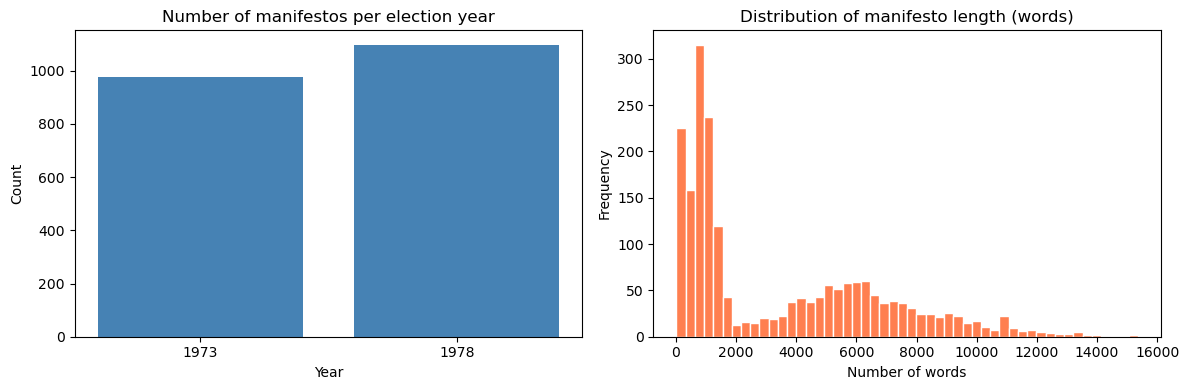


Word count summary:
count     2072.0
mean      3470.0
std       3346.0
min         19.0
25%        758.0
50%       1482.0
75%       6003.0
max      15359.0
Name: n_words, dtype: float64


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 4a. Number of manifestos per year
counts = df_manifestos.groupby("year").size()
axes[0].bar(counts.index, counts.values, color="steelblue")
axes[0].set_title("Number of manifestos per election year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

# 4b. Word count distribution
axes[1].hist(df_manifestos["n_words"], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Distribution of manifesto length (words)")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "fig_descriptive.png", dpi=150)
plt.show()

print("\nWord count summary:")
print(df_manifestos["n_words"].describe().round(0))

## 5. Inspect OCR quality

We look at a random manifesto and compute a rough noise score:  
ratio of non-alphabetic characters (digits, symbols) to total characters.

In [44]:
# Print a sample manifesto to eyeball OCR quality
sample = df_manifestos.sample(1, random_state=42).iloc[0]
print(f"Year: {sample.year} | Pages: {sample.n_pages} | Words: {sample.n_words}")
print("-" * 60)
print(sample.full_text[:800])

Year: 1978 | Pages: 8 | Words: 6902
------------------------------------------------------------
RÉPUBLIQUE FRANÇAISE - 5e CIRCONSCRIPTION DE LA LOIRE
Elections Législatives de Mars 1978
PARTI SOCIALISTE
CANDIDAT JEAN AUROUX Maire de Roanne Conseiller Général
MARS 1978 : UNE ÉCHÉANCE CAPITALE POUR L'AVENIR DE NOTRE PAYS OÙ VOUS AVEZ VOTRE RESPONSABILITÉ
REMPLAÇANT ÉVENTUEL J.J. BENETIÈRE
En élisant un nouveau Parlement les 12 et 19 mars prochains, les Françaises et les Français décideront de la nouvelle majorité qui sera appelée à conduire les affaires du pays.
Électrices et électeurs de la 5e circonscription de la Loire, le choix est simple.
Ou bien vous soutenez un candidat de la majorité, et vous reconduisez les mêmes dirigeants qui défendront les mêmes intérêts et poursuivront la politique dont vous mesurez les méfaits. En renouvelant votre confiance au député sortant qui est asso


In [45]:
def ocr_noise_score(text):
    """Ratio of non-letter, non-space characters — proxy for OCR noise."""
    if len(text) == 0:
        return 0
    noise = sum(1 for c in text if not c.isalpha() and not c.isspace())
    return noise / len(text)

df_manifestos["ocr_noise"] = df_manifestos["full_text"].apply(ocr_noise_score)

print("OCR noise score by year (lower = cleaner):")
print(df_manifestos.groupby("year")["ocr_noise"].mean().round(3))

OCR noise score by year (lower = cleaner):
year
1973    0.046
1978    0.046
Name: ocr_noise, dtype: float64


## 6. Download Archelec metadata

The metadata CSV from archelec.sciencespo.fr contains one row per candidate with:
- `titulaire-sexe` — sex of the candidate (M/F) ← **our key variable**
- `titulaire-profession` — profession
- `titulaire-soutien` — political support/party
- `election-date`, `departement`, `circonscription`

**Action required:** Go to https://archelec.sciencespo.fr/explorer, click Export → CSV, and save it to `../data/archelec_metadata.csv`

Then run the cell below.

In [46]:
METADATA_PATH = PROJECT_ROOT / "data" / "archelec_metadata.csv"

if not METADATA_PATH.exists():
    print("Metadata file not found. Please download it from archelec.sciencespo.fr/explorer")
else:
    df_meta = pd.read_csv(METADATA_PATH, sep=",", encoding="utf-8")
    print(f"Metadata rows: {len(df_meta):,}")
    print(f"Columns: {df_meta.columns.tolist()}")
    df_meta.head(3)

Metadata rows: 33,031
Columns: ['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour', 'cote', 'departement', 'departement-nom', 'departement-insee', 'identifiant de circonscription', 'images', 'pdf', 'ocr_url', 'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age', 'titulaire-age-calcule', 'titulaire-age-tranche', 'titulaire-profession', 'titulaire-mandat-en-cours', 'titulaire-mandat-passe', 'titulaire-associations', 'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste', 'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom', 'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule', 'suppleant-age-tranche', 'suppleant-profession', 'suppleant-mandat-en-cours', 'suppleant-mandat-passe', 'suppleant-associations', 'suppleant-autres-statuts', 'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations']


/var/folders/l4/9495mdtj3mvf9dpmqvxz440c0000gn/T/ipykernel_81769/4013084500.py:6: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv(METADATA_PATH, sep=",", encoding="utf-8")


Gender column: 'titulaire-sexe'
titulaire-sexe
homme            29607
femme             2423
non déterminé     1001
Name: count, dtype: int64


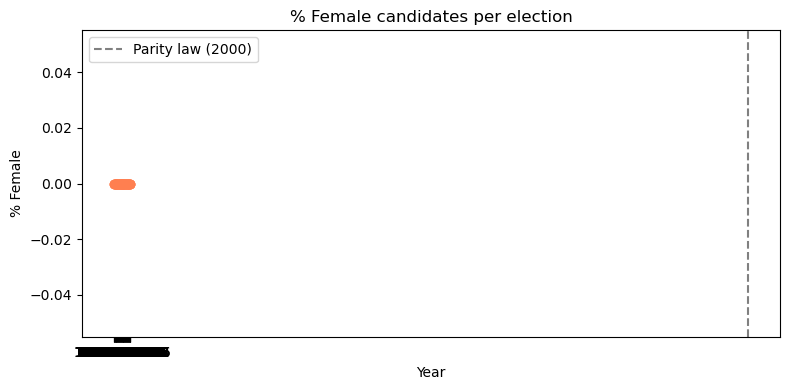

In [47]:
# Once metadata is loaded, inspect gender distribution
if METADATA_PATH.exists():
    sex_col = [c for c in df_meta.columns if "sexe" in c.lower()][0]
    print(f"Gender column: '{sex_col}'")
    print(df_meta[sex_col].value_counts())

    # Female candidates over time
    date_col = [c for c in df_meta.columns if "date" in c.lower() or "annee" in c.lower()][0]
    pct_female = (
        df_meta.groupby(date_col)[sex_col]
        .apply(lambda x: (x == "F").sum() / len(x) * 100)
        .reset_index(name="pct_female")
    )
    plt.figure(figsize=(8, 4))
    plt.plot(pct_female[date_col], pct_female["pct_female"], marker="o", color="coral")
    plt.title("% Female candidates per election")
    plt.xlabel("Year")
    plt.ylabel("% Female")
    plt.axvline(x=2000, color="gray", linestyle="--", label="Parity law (2000)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "notebooks" / "fig_female_pct.png", dpi=150)
    plt.show()

## 7. Summary

By the end of this notebook you should have:
- [ ] Total manifesto count per year
- [ ] Word length distribution plot
- [ ] OCR noise assessment
- [ ] % Female candidates per election (once metadata downloaded)

**Next:** `02_ner_pipeline.ipynb` — extract person names from the manifestos using CamemBERT-NER.